<a href="https://colab.research.google.com/github/Asmitpremkumar16/Customer_Churn/blob/main/Churn_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Asmitpremkumar16/Customer_Churn.git

Cloning into 'Customer_Churn'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 24 (delta 5), reused 13 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 433.41 KiB | 2.27 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [2]:
%cd Customer_Churn/

/content/Customer_Churn


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
data= pd.read_csv(r"/content/Customer_Churn/churn modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
data.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [87]:
data.groupby('Geography')['Exited'].mean() * 100

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


In [88]:
data.groupby('Gender')['Exited'].mean() * 100

,Exited
Gender,
Female,25.071539
Male,16.455928


In [75]:
data.groupby(['Geography','Gender'])['Exited'].mean() * 100

Geography  Gender
France     Female    20.344980
           Male      12.713404
Germany    Female    37.552389
           Male      27.811550
Spain      Female    21.212121
           Male      13.112392
Name: Exited, dtype: float64

In [71]:
data.groupby(['Gender','IsActiveMember'])['Exited'].mean() * 100

Gender  IsActiveMember
Female  0                 32.093847
        1                 18.126095
Male    0                 22.277992
        1                 11.196373
Name: Exited, dtype: float64

In [76]:
data.groupby(['NumOfProducts','IsActiveMember'])['Exited'].mean() * 100

NumOfProducts  IsActiveMember
1              0                  36.652122
               1                  18.923137
2              0                   9.888060
               1                   5.560098
3              0                  88.235294
               1                  75.221239
4              0                 100.000000
               1                 100.000000
Name: Exited, dtype: float64

In [85]:
data.groupby(['HasCrCard'])['Exited'].mean() * 100

,Exited
HasCrCard,
0,20.814941
1,20.184266


In [52]:
fig1= px.histogram(data, x= "Geography", color= "IsActiveMember",facet_col= "Exited", barmode= "group", title= "Geography by Exited")
fig1.show()

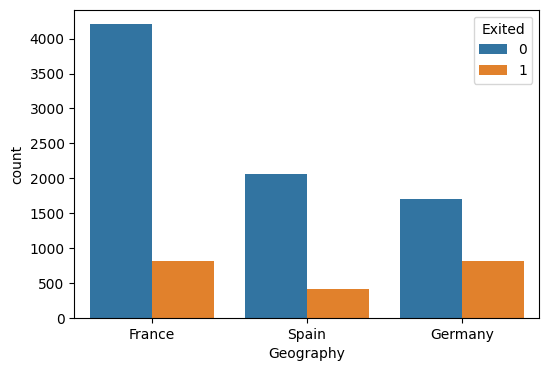

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(data= data, x= "Geography", hue= "Exited")
plt.show()

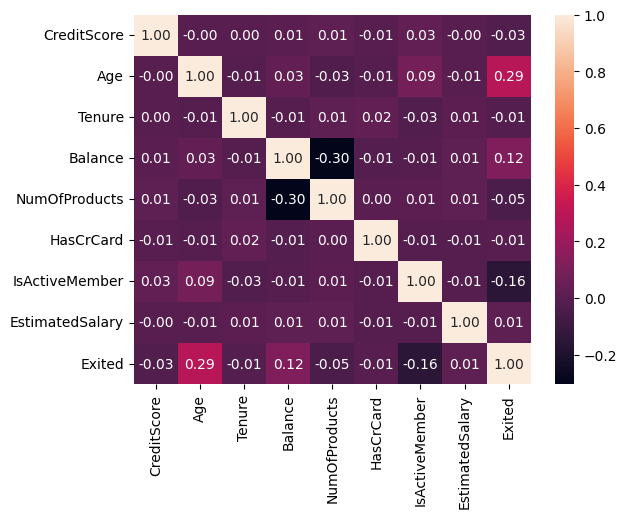

In [10]:
df= data[["CreditScore","Age","Tenure","Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary","Exited"]].corr()
sns.heatmap(df, annot= True, fmt= ".2f")
plt.show()

In [20]:
fig2= px.imshow(df, text_auto= ".2f",title= "Correlation Heatmap")
fig2.update_layout(width= 700, height= 600)
fig2.show()

In [36]:
data['Age'].describe()

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


In [66]:
fig5= px.histogram(data, x= "Age", color= "Exited", barmode= 'overlay', title= "Age Distribution Churned vs Retained", opacity= 0.6)
fig5.show()

In [80]:
fig6= px.histogram(data, x= "EstimatedSalary", color= "Exited", opacity= 0.6, title= "Churn across different Balance")
fig6.show()